## Baseline Decision Logic

The baseline combines image-based person detection, the supplied `person_score`, `red_score`, and V2X information to produce **STOP, SLOW, or GO**. The conditions are evaluated sequentially, and the first satisfied condition immediately determines the decision.

### Person Detection and Road Boundary

The image is analysed at **row \(v=235\)**. Pixel brightness is calculated as \(R+G+B\). Pixels with brightness **≤ 150** are treated as black. Black pixels separated by at most **3 pixels** are grouped, groups smaller than **2 pixels** are discarded, and the two largest groups are treated as the person's two legs. The rightmost pixel of the right-leg group is used to determine the person's position relative to the road boundary.

For road-boundary detection, the maximum brightness must be **≥ 650**. Among pixels having the maximum brightness, the leftmost pixel is taken as the **left road boundary** and the rightmost pixel as the **right road boundary**. The boundary pair is considered valid only when their separation is **≥ 10 pixels**.

The image-based person score is assigned as follows:

- Fewer than two leg groups detected → `image_person_score = 0.0`
- Maximum brightness < 650 → `image_person_score = 1.0`
- Boundary gap < 10 pixels → `image_person_score = 1.0`
- Rightmost right-leg pixel < right boundary → `image_person_score = 1.0`
- Otherwise → `image_person_score = 0.5`

### Exact Decision Sequence

The baseline follows the **exact order implemented in the code**:

1. `image_person_score > 0.8` → **STOP**
2. `0.5 ≤ image_person_score ≤ 0.8` → **SLOW**
3. `person_score > 0.8` → **STOP**
4. `red_score > 0.8` → **STOP**
5. `v2x_light == "red"` → **STOP**
6. `0.5 ≤ person_score ≤ 0.8` → **SLOW**
7. `0.5 ≤ red_score ≤ 0.8` → **SLOW**
8. If none of the above conditions is satisfied → **GO**


Because the function returns immediately when a condition is satisfied, an earlier condition can override evidence checked later. For example, if `image_person_score = 0.5` and `red_score = 0.95`, the system returns **SLOW** at Step 2 and never reaches the red-light STOP condition.

### Thresholds and Assumptions

- Row used for image analysis: **\(v=235\)**
- Black-pixel threshold: **150**
- Maximum gap for grouping black pixels: **3 pixels**
- Minimum group size: **2 pixels**
- Number of leg groups required: **2**
- Road-boundary brightness threshold: **650**
- Minimum boundary separation: **10 pixels**
- STOP threshold for person/red scores: **> 0.8**
- SLOW range for person/red scores: **0.5–0.8**
- `person_score` and `red_score` are treated as evidence scores, not calibrated probabilities.
- V2X `red` is treated as STOP evidence.
- Reference labels are not used in the baseline decision.


PERSON CROSSING — BASELINE DECISION TIMELINE
Frame 00 | t=0.00s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 01 | t=0.10s | person=0.113 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 02 | t=0.20s | person=0.010 | image_person=0.0 | red=0.028 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 03 | t=0.30s | person=0.153 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 04 | t=0.40s | person=0.456 | image_person=0.0 | red=0.040 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 05 | t=0.50s | person=0.219 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 06 | t=0.60s | person=0.770 | image_person=0.0 | red=0.365 | V2X=green | SLOW | Moderate person_score
Frame 07 | t=0.70s | person=0.770 | image_person=0.0 | red=0.094 | V2X=green | SLOW | Moderate person_score
Frame 08 | t=0.80s

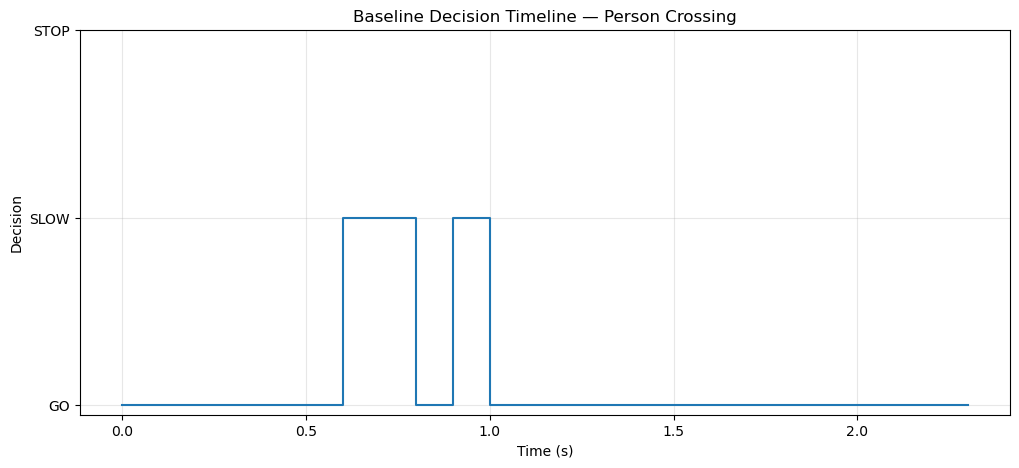


PERSON CROSSING — BASELINE DECISION TIMELINE
Frame 00 | t=0.00s | person=0.146 | image_person=0.0 | red=0.090 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 01 | t=0.10s | person=0.541 | image_person=0.0 | red=0.010 | V2X=green | SLOW | Moderate person_score
Frame 02 | t=0.20s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 03 | t=0.30s | person=0.335 | image_person=0.0 | red=0.017 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 04 | t=0.40s | person=0.078 | image_person=0.0 | red=0.108 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 05 | t=0.50s | person=0.192 | image_person=0.0 | red=0.078 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 06 | t=0.60s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 07 | t=0.70s | person=0.010 | image_person=0.0 | red=0.069 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 

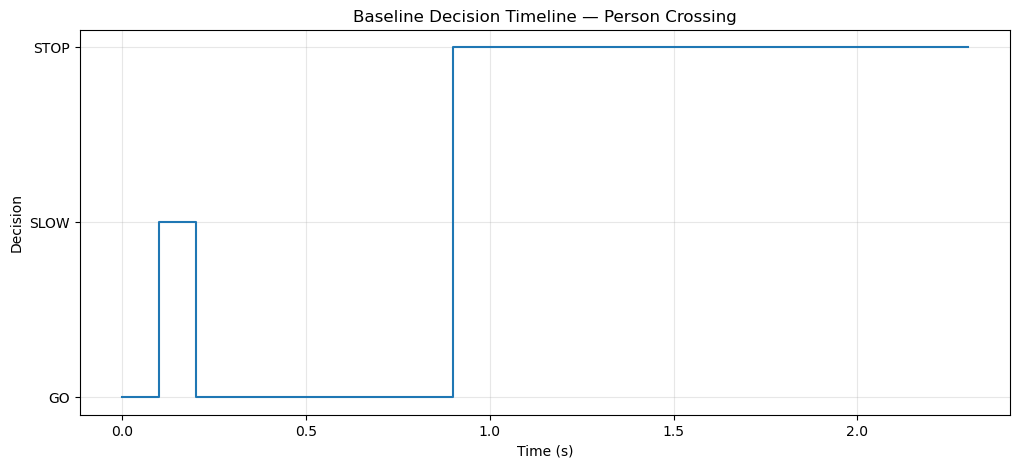


PERSON CROSSING — BASELINE DECISION TIMELINE
Frame 00 | t=0.00s | person=0.187 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 01 | t=0.10s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 02 | t=0.20s | person=0.010 | image_person=0.0 | red=0.224 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 03 | t=0.30s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 04 | t=0.40s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 05 | t=0.50s | person=0.010 | image_person=0.0 | red=0.142 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 06 | t=0.60s | person=0.010 | image_person=0.0 | red=0.121 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 07 | t=0.70s | person=0.824 | image_person=0.5 | red=0.010 | V2X=green | SLOW | Person detected but road occ

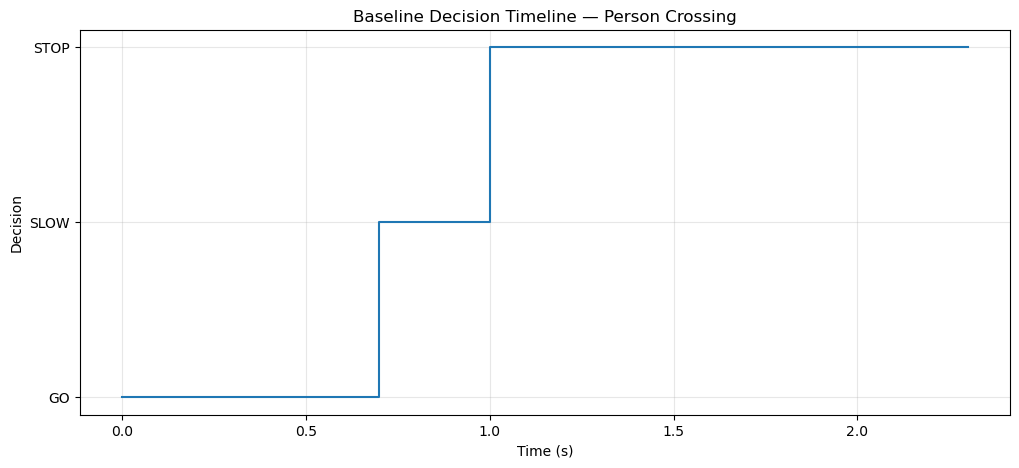

Black pixel positions:
[353 354 355 356 364 365 366 367 368]

Brightness of each black pixel:
u = 353, RGB = [24 35 43], brightness = 102
u = 354, RGB = [24 35 43], brightness = 102
u = 355, RGB = [24 35 43], brightness = 102
u = 356, RGB = [24 35 43], brightness = 102
u = 364, RGB = [24 35 43], brightness = 102
u = 365, RGB = [24 35 43], brightness = 102
u = 366, RGB = [24 35 43], brightness = 102
u = 367, RGB = [24 35 43], brightness = 102
u = 368, RGB = [24 35 43], brightness = 102


In [70]:
import cv2
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 1. IMAGE-BASED PERSON SCORE
# ============================================================

def get_image_person_score(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return 0.0

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # Check row v = 235
    # --------------------------------------------------------

    v = 235
    row = img[v]

    # Brightness = R + G + B
    brightness = np.sum(row[:, :3], axis=1)

    # --------------------------------------------------------
    # Detect black pixels
    # --------------------------------------------------------

    # Black-pixel threshold = 150
    black_pixels = np.where(brightness <= 150)[0]

    # --------------------------------------------------------
    # Group nearby black pixels
    # --------------------------------------------------------

    groups = []

    if len(black_pixels) > 0:

        current_group = [black_pixels[0]]

        for i in range(1, len(black_pixels)):

            # Pixels within 3 positions are considered
            # part of the same group
            if black_pixels[i] - black_pixels[i - 1] <= 3:

                current_group.append(black_pixels[i])

            else:

                if len(current_group) >= 2:
                    groups.append(current_group)

                current_group = [black_pixels[i]]

        # Add final group
        if len(current_group) >= 2:
            groups.append(current_group)

    # --------------------------------------------------------
    # Need two groups = two legs
    # --------------------------------------------------------

    if len(groups) < 2:

        return 0.0

    # Take two largest groups
    groups = sorted(
        groups,
        key=len,
        reverse=True
    )[:2]

    # Sort groups from left → right
    groups = sorted(
        groups,
        key=lambda g: np.mean(g)
    )

    left_leg = groups[0]
    right_leg = groups[1]

    # Rightmost pixel of right leg
    right_leg_rightmost = max(right_leg)

    # --------------------------------------------------------
    # Detect RIGHT ROAD BOUNDARY
    # --------------------------------------------------------

    max_brightness = np.max(brightness)

    # Road-boundary brightness threshold = 650
    if max_brightness < 650:

        # No right boundary detected.
        # Since two legs are detected, conclude
        # that the person is on the road.

        return 1.0

    # --------------------------------------------------------
    # Find LEFT and RIGHT road boundaries
    # --------------------------------------------------------

    brightest_pixels = np.where(
        brightness == max_brightness
    )[0]

    # Leftmost brightest pixel = left boundary
    left_boundary = np.min(brightest_pixels)

    # Rightmost brightest pixel = right boundary
    right_boundary = np.max(brightest_pixels)

    # --------------------------------------------------------
    # Check minimum gap between road boundaries
    # --------------------------------------------------------

    boundary_gap = right_boundary - left_boundary

    if boundary_gap < 10:

        # Boundaries are too close to be considered
        # a valid road boundary pair.
        #
        # Therefore the right boundary is treated
        # as NOT detected.

        return 1.0

    # --------------------------------------------------------
    # Determine whether person is on road
    # --------------------------------------------------------

    if right_leg_rightmost < right_boundary:

        # Person is inside the road
        return 1.0

    else:

        # Person detected but road occupancy is uncertain
        return 0.5


# # ============================================================
# 2. BASELINE DECISION LOGIC
# ============================================================

def baseline_decision(
    person_score,
    image_person_score,
    red_score,
    v2x_light
):

  # ========================================================
    # STEP 1 — CHECK ALL STOP CONDITIONS FIRST
    # ========================================================

    # Image-based person evidence
    if image_person_score > 0.8:

        return "STOP", "Image confirms person is on road"

    if 0.5 <= image_person_score <= 0.8:

        return "SLOW", (
            "Person detected but road occupancy uncertain"
        )

    # Secondary person evidence
    if person_score > 0.8:

        return "STOP", "High person_score"

    # Red-light evidence
    if red_score > 0.8:

        return "STOP", "High red_score"

    # V2X red signal
    if str(v2x_light).lower() == "red":

        return "STOP", "V2X reports red"


    # ========================================================
    # STEP 2 — IF NO STOP, CHECK ALL SLOW CONDITIONS
    # ======================================================== 

    # Secondary person evidence
    if 0.5 <= person_score <= 0.8:

        return "SLOW", "Moderate person_score"

    # Red-light evidence
    if 0.5 <= red_score <= 0.8:

        return "SLOW", "Moderate red_score"


    # ========================================================
    # STEP 3 — OTHERWISE GO
    # ========================================================

    return "GO", "No strong person/red/V2X evidence"
# ============================================================
# 3. LOAD CROSSING EVIDENCE
# ============================================================

evidence_path = "crossing_evidence.csv"

evidence = pd.read_csv(evidence_path)


# ============================================================
# 4. LOAD PERSON-CROSSING IMAGES
# ============================================================

image_files = sorted(
    glob.glob("clear_green/*.png"),
    key=lambda x: int(
        os.path.splitext(
            os.path.basename(x)
        )[0].split("_")[-1]
    )
)


# ============================================================
# 5. PROCESS ALL FRAMES
# ============================================================

results = []

for image_path in image_files:

    filename = os.path.basename(image_path)

    # Extract frame number
    frame_number = int(
        os.path.splitext(filename)[0].split("_")[-1]
    )

    # --------------------------------------------------------
    # Find corresponding evidence row
    # --------------------------------------------------------

    row = evidence[
        (evidence["episode"] == "clear_green") &
        (evidence["frame"] == frame_number)
    ]

    if len(row) == 0:

        print("No evidence found for:", filename)
        continue

    row = row.iloc[0]

    # CSV evidence
    time_s = row["time_s"]
    person_score = row["person_score"]
    red_score = row["red_score"]
    v2x_light = row["v2x_light"]

    # --------------------------------------------------------
    # Calculate our image-based person score
    # --------------------------------------------------------

    image_person_score = get_image_person_score(
        image_path
    )

    # --------------------------------------------------------
    # Apply baseline decision
    # --------------------------------------------------------

    decision, reason = baseline_decision(
        person_score,
        image_person_score,
        red_score,
        v2x_light
    )

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "frame": frame_number,

        "time_s": time_s,

        "person_score": person_score,

        "image_person_score": image_person_score,

        "red_score": red_score,

        "v2x_light": v2x_light,

        "decision": decision,

        "reason": reason
    })


# ============================================================
# 6. CREATE RESULTS DATAFRAME
# ============================================================

results_dfb1 = pd.DataFrame(results)


# ============================================================
# 7. PRINT FULL TIMELINE
# ============================================================

print("\n" + "=" * 110)

print(
    "PERSON CROSSING — BASELINE DECISION TIMELINE"
)

print("=" * 110)

for _, r in results_dfb1.iterrows():

    print(
        f"Frame {int(r['frame']):02d} | "
        f"t={r['time_s']:.2f}s | "
        f"person={r['person_score']:.3f} | "
        f"image_person={r['image_person_score']:.1f} | "
        f"red={r['red_score']:.3f} | "
        f"V2X={r['v2x_light']} | "
        f"{r['decision']:4s} | "
        f"{r['reason']}"
    )


# ============================================================
# 8. PRINT COMPACT TIMELINE
# ============================================================

print("\n")
print("COMPACT TIMELINE")
print("-" * 60)

for _, r in results_dfb1.iterrows():

    print(
        f"Frame {int(r['frame']):02d} "
        f"(t={r['time_s']:.2f}s) → "
        f"{r['decision']}"
    )


# ============================================================
# 9. PLOT DECISION TIMELINE
# ============================================================

decision_value = {
    "GO": 0,
    "SLOW": 1,
    "STOP": 2
}

y = results_dfb1["decision"].map(
    decision_value
)

plt.figure(figsize=(12, 5))

plt.step(
    results_dfb1["time_s"],
    y,
    where="post"
)

plt.yticks(
    [0, 1, 2],
    ["GO", "SLOW", "STOP"]
)

plt.xlabel("Time (s)")
plt.ylabel("Decision")

plt.title(
    "Baseline Decision Timeline — Person Crossing"
)

plt.grid(True, alpha=0.3)

plt.show()

import cv2
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 1. IMAGE-BASED PERSON SCORE
# ============================================================

def get_image_person_score(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return 0.0

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # Check row v = 235
    # --------------------------------------------------------

    v = 235
    row = img[v]

    # Brightness = R + G + B
    brightness = np.sum(row[:, :3], axis=1)

    # --------------------------------------------------------
    # Detect black pixels
    # --------------------------------------------------------

    # Black-pixel threshold = 150
    black_pixels = np.where(brightness <= 150)[0]

    # --------------------------------------------------------
    # Group nearby black pixels
    # --------------------------------------------------------

    groups = []

    if len(black_pixels) > 0:

        current_group = [black_pixels[0]]

        for i in range(1, len(black_pixels)):

            # Pixels within 3 positions are considered
            # part of the same group
            if black_pixels[i] - black_pixels[i - 1] <= 3:

                current_group.append(black_pixels[i])

            else:

                if len(current_group) >= 2:
                    groups.append(current_group)

                current_group = [black_pixels[i]]

        # Add final group
        if len(current_group) >= 2:
            groups.append(current_group)

    # --------------------------------------------------------
    # Need two groups = two legs
    # --------------------------------------------------------

    if len(groups) < 2:

        return 0.0

    # Take two largest groups
    groups = sorted(
        groups,
        key=len,
        reverse=True
    )[:2]

    # Sort groups from left → right
    groups = sorted(
        groups,
        key=lambda g: np.mean(g)
    )

    left_leg = groups[0]
    right_leg = groups[1]

    # Rightmost pixel of right leg
    right_leg_rightmost = max(right_leg)

    # --------------------------------------------------------
    # Detect RIGHT ROAD BOUNDARY
    # --------------------------------------------------------

    max_brightness = np.max(brightness)

    # Road-boundary brightness threshold = 650
    if max_brightness < 650:

        # No right boundary detected.
        # Since two legs are detected, conclude
        # that the person is on the road.

        return 1.0

    # --------------------------------------------------------
    # Find LEFT and RIGHT road boundaries
    # --------------------------------------------------------

    brightest_pixels = np.where(
        brightness == max_brightness
    )[0]

    # Leftmost brightest pixel = left boundary
    left_boundary = np.min(brightest_pixels)

    # Rightmost brightest pixel = right boundary
    right_boundary = np.max(brightest_pixels)

    # --------------------------------------------------------
    # Check minimum gap between road boundaries
    # --------------------------------------------------------

    boundary_gap = right_boundary - left_boundary

    if boundary_gap < 10:

        # Boundaries are too close to be considered
        # a valid road boundary pair.
        #
        # Therefore the right boundary is treated
        # as NOT detected.

        return 1.0

    # --------------------------------------------------------
    # Determine whether person is on road
    # --------------------------------------------------------

    if right_leg_rightmost < right_boundary:

        # Person is inside the road
        return 1.0

    else:

        # Person detected but road occupancy is uncertain
        return 0.5


# ============================================================
# 2. BASELINE DECISION LOGIC
# ============================================================

def baseline_decision(
    person_score,
    image_person_score,
    red_score,
    v2x_light
):

  # ========================================================
    # STEP 1 — CHECK ALL STOP CONDITIONS FIRST
    # ========================================================

    # Image-based person evidence
    if image_person_score > 0.8:

        return "STOP", "Image confirms person is on road"

    if 0.5 <= image_person_score <= 0.8:

        return "SLOW", (
            "Person detected but road occupancy uncertain"
        )

    # Secondary person evidence
    if person_score > 0.8:

        return "STOP", "High person_score"

    # Red-light evidence
    if red_score > 0.8:

        return "STOP", "High red_score"

    # V2X red signal
    if str(v2x_light).lower() == "red":

        return "STOP", "V2X reports red"


    # ========================================================
    # STEP 2 — IF NO STOP, CHECK ALL SLOW CONDITIONS
    # ======================================================== 

    # Secondary person evidence
    if 0.5 <= person_score <= 0.8:

        return "SLOW", "Moderate person_score"

    # Red-light evidence
    if 0.5 <= red_score <= 0.8:

        return "SLOW", "Moderate red_score"


    # ========================================================
    # STEP 3 — OTHERWISE GO
    # ========================================================

    return "GO", "No strong person/red/V2X evidence"
# ============================================================
# 3. LOAD CROSSING EVIDENCE
# ============================================================

evidence_path = "crossing_evidence.csv"

evidence = pd.read_csv(evidence_path)


# ============================================================
# 4. LOAD PERSON-CROSSING IMAGES
# ============================================================

image_files = sorted(
    glob.glob("late_red/*.png"),
    key=lambda x: int(
        os.path.splitext(
            os.path.basename(x)
        )[0].split("_")[-1]
    )
)


# ============================================================
# 5. PROCESS ALL FRAMES
# ============================================================

results = []

for image_path in image_files:

    filename = os.path.basename(image_path)

    # Extract frame number
    frame_number = int(
        os.path.splitext(filename)[0].split("_")[-1]
    )

    # --------------------------------------------------------
    # Find corresponding evidence row
    # --------------------------------------------------------

    row = evidence[
        (evidence["episode"] == "late_red") &
        (evidence["frame"] == frame_number)
    ]

    if len(row) == 0:

        print("No evidence found for:", filename)
        continue

    row = row.iloc[0]

    # CSV evidence
    time_s = row["time_s"]
    person_score = row["person_score"]
    red_score = row["red_score"]
    v2x_light = row["v2x_light"]

    # --------------------------------------------------------
    # Calculate our image-based person score
    # --------------------------------------------------------

    image_person_score = get_image_person_score(
        image_path
    )

    # --------------------------------------------------------
    # Apply baseline decision
    # --------------------------------------------------------

    decision, reason = baseline_decision(
        person_score,
        image_person_score,
        red_score,
        v2x_light
    )

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "frame": frame_number,

        "time_s": time_s,

        "person_score": person_score,

        "image_person_score": image_person_score,

        "red_score": red_score,

        "v2x_light": v2x_light,

        "decision": decision,

        "reason": reason
    })


# ============================================================
# 6. CREATE RESULTS DATAFRAME
# ============================================================

results_dfb2 = pd.DataFrame(results)


# ============================================================
# 7. PRINT FULL TIMELINE
# ============================================================

print("\n" + "=" * 110)

print(
    "PERSON CROSSING — BASELINE DECISION TIMELINE"
)

print("=" * 110)

for _, r in results_dfb2.iterrows():

    print(
        f"Frame {int(r['frame']):02d} | "
        f"t={r['time_s']:.2f}s | "
        f"person={r['person_score']:.3f} | "
        f"image_person={r['image_person_score']:.1f} | "
        f"red={r['red_score']:.3f} | "
        f"V2X={r['v2x_light']} | "
        f"{r['decision']:4s} | "
        f"{r['reason']}"
    )


# ============================================================
# 8. PRINT COMPACT TIMELINE
# ============================================================

print("\n")
print("COMPACT TIMELINE")
print("-" * 60)

for _, r in results_dfb2.iterrows():

    print(
        f"Frame {int(r['frame']):02d} "
        f"(t={r['time_s']:.2f}s) → "
        f"{r['decision']}"
    )


# ============================================================
# 9. PLOT DECISION TIMELINE
# ============================================================

decision_value = {
    "GO": 0,
    "SLOW": 1,
    "STOP": 2
}

y = results_dfb2["decision"].map(
    decision_value
)

plt.figure(figsize=(12, 5))

plt.step(
    results_dfb2["time_s"],
    y,
    where="post"
)

plt.yticks(
    [0, 1, 2],
    ["GO", "SLOW", "STOP"]
)

plt.xlabel("Time (s)")
plt.ylabel("Decision")

plt.title(
    "Baseline Decision Timeline — Person Crossing"
)

plt.grid(True, alpha=0.3)

plt.show()

import cv2
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 1. IMAGE-BASED PERSON SCORE
# ============================================================

def get_image_person_score(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return 0.0

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # Check row v = 235
    # --------------------------------------------------------

    v = 235
    row = img[v]

    # Brightness = R + G + B
    brightness = np.sum(row[:, :3], axis=1)

    # --------------------------------------------------------
    # Detect black pixels
    # --------------------------------------------------------

    # Black-pixel threshold = 150
    black_pixels = np.where(brightness <= 150)[0]

    # --------------------------------------------------------
    # Group nearby black pixels
    # --------------------------------------------------------

    groups = []

    if len(black_pixels) > 0:

        current_group = [black_pixels[0]]

        for i in range(1, len(black_pixels)):

            # Pixels within 3 positions are considered
            # part of the same group
            if black_pixels[i] - black_pixels[i - 1] <= 3:

                current_group.append(black_pixels[i])

            else:

                if len(current_group) >= 2:
                    groups.append(current_group)

                current_group = [black_pixels[i]]

        # Add final group
        if len(current_group) >= 2:
            groups.append(current_group)

    # --------------------------------------------------------
    # Need two groups = two legs
    # --------------------------------------------------------

    if len(groups) < 2:

        return 0.0

    # Take two largest groups
    groups = sorted(
        groups,
        key=len,
        reverse=True
    )[:2]

    # Sort groups from left → right
    groups = sorted(
        groups,
        key=lambda g: np.mean(g)
    )

    left_leg = groups[0]
    right_leg = groups[1]

    # Rightmost pixel of right leg
    right_leg_rightmost = max(right_leg)

    # --------------------------------------------------------
    # Detect RIGHT ROAD BOUNDARY
    # --------------------------------------------------------

    max_brightness = np.max(brightness)

    # Road-boundary brightness threshold = 650
    if max_brightness < 650:

        # No right boundary detected.
        # Since two legs are detected, conclude
        # that the person is on the road.

        return 1.0

    # --------------------------------------------------------
    # Find LEFT and RIGHT road boundaries
    # --------------------------------------------------------

    brightest_pixels = np.where(
        brightness == max_brightness
    )[0]

    # Leftmost brightest pixel = left boundary
    left_boundary = np.min(brightest_pixels)

    # Rightmost brightest pixel = right boundary
    right_boundary = np.max(brightest_pixels)

    # --------------------------------------------------------
    # Check minimum gap between road boundaries
    # --------------------------------------------------------

    boundary_gap = right_boundary - left_boundary

    if boundary_gap < 10:

        # Boundaries are too close to be considered
        # a valid road boundary pair.
        #
        # Therefore the right boundary is treated
        # as NOT detected.

        return 1.0

    # --------------------------------------------------------
    # Determine whether person is on road
    # --------------------------------------------------------

    if right_leg_rightmost < right_boundary:

        # Person is inside the road
        return 1.0

    else:

        # Person detected but road occupancy is uncertain
        return 0.5


# ============================================================
# 2. BASELINE DECISION LOGIC
# ============================================================

def baseline_decision(
    person_score,
    image_person_score,
    red_score,
    v2x_light
):

    # ========================================================
    # STEP 1 — CHECK ALL STOP CONDITIONS FIRST
    # ========================================================

    # Image-based person evidence
    if image_person_score > 0.8:

        return "STOP", "Image confirms person is on road"

    if 0.5 <= image_person_score <= 0.8:

        return "SLOW", (
            "Person detected but road occupancy uncertain"
        )

    # Secondary person evidence
    if person_score > 0.8:

        return "STOP", "High person_score"

    # Red-light evidence
    if red_score > 0.8:

        return "STOP", "High red_score"

    # V2X red signal
    if str(v2x_light).lower() == "red":

        return "STOP", "V2X reports red"


    # ========================================================
    # STEP 2 — IF NO STOP, CHECK ALL SLOW CONDITIONS
    # ======================================================== 

    # Secondary person evidence
    if 0.5 <= person_score <= 0.8:

        return "SLOW", "Moderate person_score"

    # Red-light evidence
    if 0.5 <= red_score <= 0.8:

        return "SLOW", "Moderate red_score"


    # ========================================================
    # STEP 3 — OTHERWISE GO
    # ========================================================

    return "GO", "No strong person/red/V2X evidence"
# ============================================================
# 3. LOAD CROSSING EVIDENCE
# ============================================================

evidence_path = "crossing_evidence.csv"

evidence = pd.read_csv(evidence_path)


# ============================================================
# 4. LOAD PERSON-CROSSING IMAGES
# ============================================================

image_files = sorted(
    glob.glob("person_crossing/*.png"),
    key=lambda x: int(
        os.path.splitext(
            os.path.basename(x)
        )[0].split("_")[-1]
    )
)


# ============================================================
# 5. PROCESS ALL FRAMES
# ============================================================

results = []

for image_path in image_files:

    filename = os.path.basename(image_path)

    # Extract frame number
    frame_number = int(
        os.path.splitext(filename)[0].split("_")[-1]
    )

    # --------------------------------------------------------
    # Find corresponding evidence row
    # --------------------------------------------------------

    row = evidence[
        (evidence["episode"] == "person_crossing") &
        (evidence["frame"] == frame_number)
    ]

    if len(row) == 0:

        print("No evidence found for:", filename)
        continue

    row = row.iloc[0]

    # CSV evidence
    time_s = row["time_s"]
    person_score = row["person_score"]
    red_score = row["red_score"]
    v2x_light = row["v2x_light"]

    # --------------------------------------------------------
    # Calculate our image-based person score
    # --------------------------------------------------------

    image_person_score = get_image_person_score(
        image_path
    )

    # --------------------------------------------------------
    # Apply baseline decision
    # --------------------------------------------------------

    decision, reason = baseline_decision(
        person_score,
        image_person_score,
        red_score,
        v2x_light
    )

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "frame": frame_number,

        "time_s": time_s,

        "person_score": person_score,

        "image_person_score": image_person_score,

        "red_score": red_score,

        "v2x_light": v2x_light,

        "decision": decision,

        "reason": reason
    })


# ============================================================
# 6. CREATE RESULTS DATAFRAME
# ============================================================

results_dfb3= pd.DataFrame(results)


# ============================================================
# 7. PRINT FULL TIMELINE
# ============================================================

print("\n" + "=" * 110)

print(
    "PERSON CROSSING — BASELINE DECISION TIMELINE"
)

print("=" * 110)

for _, r in results_dfb3.iterrows():

    print(
        f"Frame {int(r['frame']):02d} | "
        f"t={r['time_s']:.2f}s | "
        f"person={r['person_score']:.3f} | "
        f"image_person={r['image_person_score']:.1f} | "
        f"red={r['red_score']:.3f} | "
        f"V2X={r['v2x_light']} | "
        f"{r['decision']:4s} | "
        f"{r['reason']}"
    )


# ============================================================
# 8. PRINT COMPACT TIMELINE
# ============================================================

print("\n")
print("COMPACT TIMELINE")
print("-" * 60)

for _, r in results_dfb3.iterrows():

    print(
        f"Frame {int(r['frame']):02d} "
        f"(t={r['time_s']:.2f}s) → "
        f"{r['decision']}"
    )


# ============================================================
# 9. PLOT DECISION TIMELINE
# ============================================================

decision_value = {
    "GO": 0,
    "SLOW": 1,
    "STOP": 2
}

y = results_dfb3["decision"].map(
    decision_value
)

plt.figure(figsize=(12, 5))

plt.step(
    results_dfb3["time_s"],
    y,
    where="post"
)

plt.yticks(
    [0, 1, 2],
    ["GO", "SLOW", "STOP"]
)

plt.xlabel("Time (s)")
plt.ylabel("Decision")

plt.title(
    "Baseline Decision Timeline — Person Crossing"
)

plt.grid(True, alpha=0.3)

plt.show()



In [71]:
import cv2
import numpy as np

# Load image
img = cv2.imread("person_crossing/010.png")

# Convert BGR → RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Row v = 235
v = 233
row = img[v]

# Calculate brightness = R + G + B
brightness = np.sum(row[:, :3], axis=1)

# Find pixels that we are considering black
black_pixels = np.where(brightness <= 150)[0]

print("Black pixel positions:")
print(black_pixels)

print("\nBrightness of each black pixel:")
for u in black_pixels:
    print(f"u = {u}, RGB = {row[u]}, brightness = {brightness[u]}")

Black pixel positions:
[353 354 355 356 364 365 366 367 368]

Brightness of each black pixel:
u = 353, RGB = [24 35 43], brightness = 102
u = 354, RGB = [24 35 43], brightness = 102
u = 355, RGB = [24 35 43], brightness = 102
u = 356, RGB = [24 35 43], brightness = 102
u = 364, RGB = [24 35 43], brightness = 102
u = 365, RGB = [24 35 43], brightness = 102
u = 366, RGB = [24 35 43], brightness = 102
u = 367, RGB = [24 35 43], brightness = 102
u = 368, RGB = [24 35 43], brightness = 102


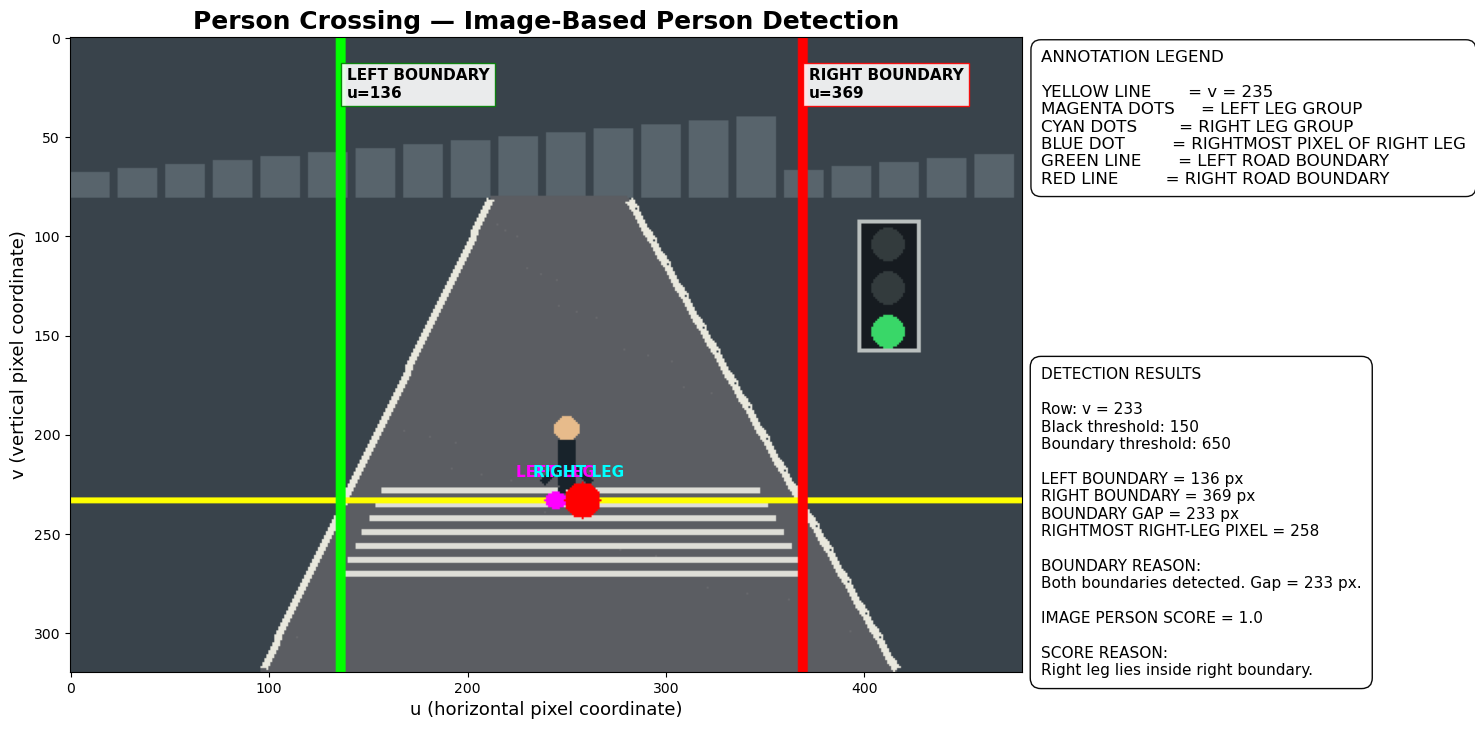

In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# IMAGE
# ============================================================

image_path = "person_crossing/021.png"

img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

height, width = img_rgb.shape[:2]


# ============================================================
# 1. ROW v = 233
# ============================================================

v = 233

row = img_rgb[v]

brightness = np.sum(
    row[:, :3],
    axis=1
)


# ============================================================
# 2. BLACK PIXELS
# ============================================================

black_threshold = 150

black_pixels = np.where(
    brightness <= black_threshold
)[0]


# ============================================================
# 3. GROUP BLACK PIXELS
# ============================================================

groups = []

if len(black_pixels) > 0:

    current_group = [black_pixels[0]]

    for i in range(1, len(black_pixels)):

        if black_pixels[i] - black_pixels[i - 1] <= 3:

            current_group.append(
                black_pixels[i]
            )

        else:

            if len(current_group) >= 2:
                groups.append(current_group)

            current_group = [black_pixels[i]]

    if len(current_group) >= 2:
        groups.append(current_group)


# ============================================================
# 4. TWO LARGEST GROUPS = TWO LEGS
# ============================================================

if len(groups) >= 2:

    groups = sorted(
        groups,
        key=len,
        reverse=True
    )[:2]

    groups = sorted(
        groups,
        key=lambda g: np.mean(g)
    )

    left_leg = groups[0]
    right_leg = groups[1]

else:

    left_leg = []
    right_leg = []


# ============================================================
# 5. RIGHTMOST PIXEL OF RIGHT LEG
# ============================================================

if len(right_leg) > 0:

    right_leg_rightmost = max(right_leg)

else:

    right_leg_rightmost = None


# ============================================================
# 6. ROAD BOUNDARIES
# ============================================================

boundary_threshold = 650

max_brightness = np.max(brightness)

left_boundary = None
right_boundary = None
boundary_gap = None

if max_brightness < 650:

    boundary_reason = (
        f"No boundary detected: "
        f"maximum brightness = {max_brightness} "
        f"< 650."
    )

else:

    brightest_pixels = np.where(
        brightness == max_brightness
    )[0]

    left_boundary_candidate = np.min(
        brightest_pixels
    )

    right_boundary_candidate = np.max(
        brightest_pixels
    )

    boundary_gap = (
        right_boundary_candidate
        - left_boundary_candidate
    )

    if boundary_gap >= 10:

        left_boundary = (
            left_boundary_candidate
        )

        right_boundary = (
            right_boundary_candidate
        )

        boundary_reason = (
            f"Both boundaries detected. "
            f"Gap = {boundary_gap} px."
        )

    else:

        boundary_reason = (
            f"Boundary pair invalid: "
            f"gap = {boundary_gap} px < 10."
        )


# ============================================================
# 7. IMAGE PERSON SCORE
# EXACTLY AS YOUR FINAL CODE
# ============================================================

if len(groups) < 2:

    image_person_score = 0.0

    score_reason = (
        "Fewer than two leg groups detected."
    )

elif max_brightness < 650:

    image_person_score = 1.0

    score_reason = (
        "No boundary detected; "
        "person classified as on road."
    )

elif boundary_gap < 10:

    image_person_score = 1.0

    score_reason = (
        "Boundary gap < 10 px; "
        "person classified as on road."
    )

elif right_leg_rightmost < right_boundary:

    image_person_score = 1.0

    score_reason = (
        "Right leg lies inside right boundary."
    )

else:

    image_person_score = 0.5

    score_reason = (
        "Person detected but road occupancy "
        "is uncertain."
    )


# ============================================================
# 8. ANNOTATED IMAGE
# ============================================================

annotated = img_rgb.copy()


# ------------------------------------------------------------
# v = 235
# ------------------------------------------------------------

cv2.line(
    annotated,
    (0, v),
    (width - 1, v),
    (255, 255, 0),
    2
)


# ------------------------------------------------------------
# LEFT LEG
# ------------------------------------------------------------

for u in left_leg:

    cv2.circle(
        annotated,
        (int(u), v),
        4,
        (255, 0, 255),
        -1
    )


# ------------------------------------------------------------
# RIGHT LEG
# ------------------------------------------------------------

for u in right_leg:

    cv2.circle(
        annotated,
        (int(u), v),
        4,
        (0, 255, 255),
        -1
    )


# ------------------------------------------------------------
# RIGHTMOST PIXEL OF RIGHT LEG
# ------------------------------------------------------------

if right_leg_rightmost is not None:

    cv2.circle(
        annotated,
        (
            int(right_leg_rightmost),
            v
        ),
        9,
        (255, 0, 0),
        -1
    )


# ------------------------------------------------------------
# LEFT BOUNDARY
# ------------------------------------------------------------

if left_boundary is not None:

    cv2.line(
        annotated,
        (
            int(left_boundary),
            0
        ),
        (
            int(left_boundary),
            height - 1
        ),
        (0, 255, 0),
        4
    )


# ------------------------------------------------------------
# RIGHT BOUNDARY
# ------------------------------------------------------------

if right_boundary is not None:

    cv2.line(
        annotated,
        (
            int(right_boundary),
            0
        ),
        (
            int(right_boundary),
            height - 1
        ),
        (255, 0, 0),
        4
    )


# ============================================================
# 9. PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 10)
)

ax.imshow(annotated)

ax.set_xlabel(
    "u (horizontal pixel coordinate)",
    fontsize=13
)

ax.set_ylabel(
    "v (vertical pixel coordinate)",
    fontsize=13
)

ax.set_title(
    "Person Crossing — Image-Based Person Detection",
    fontsize=18,
    fontweight="bold"
)


# ============================================================
# 10. LEGEND
# ============================================================

legend_text = [
    "ANNOTATION LEGEND",
    "",
    "YELLOW LINE       = v = 235",
    "MAGENTA DOTS     = LEFT LEG GROUP",
    "CYAN DOTS        = RIGHT LEG GROUP",
    "BLUE DOT         = RIGHTMOST PIXEL OF RIGHT LEG",
    "GREEN LINE       = LEFT ROAD BOUNDARY",
    "RED LINE         = RIGHT ROAD BOUNDARY",
]

legend_text = "\n".join(legend_text)

ax.text(
    1.02,
    0.98,
    legend_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="black",
        alpha=0.95
    )
)


# ============================================================
# 11. DETECTION INFORMATION BOX
# ============================================================

if left_boundary is not None:

    left_text = (
        f"LEFT BOUNDARY = {left_boundary} px"
    )

else:

    left_text = (
        "LEFT BOUNDARY = NOT DETECTED"
    )


if right_boundary is not None:

    right_text = (
        f"RIGHT BOUNDARY = {right_boundary} px"
    )

else:

    right_text = (
        "RIGHT BOUNDARY = NOT DETECTED / INVALID"
    )


if boundary_gap is not None:

    gap_text = (
        f"BOUNDARY GAP = {boundary_gap} px"
    )

else:

    gap_text = (
        "BOUNDARY GAP = N/A"
    )


if right_leg_rightmost is not None:

    leg_text = (
        f"RIGHTMOST RIGHT-LEG PIXEL = "
        f"{right_leg_rightmost}"
    )

else:

    leg_text = (
        "RIGHTMOST RIGHT-LEG PIXEL = N/A"
    )


info_text = (
    "DETECTION RESULTS\n"
    "\n"
    f"Row: v = {v}\n"
    f"Black threshold: 150\n"
    f"Boundary threshold: 650\n"
    "\n"
    f"{left_text}\n"
    f"{right_text}\n"
    f"{gap_text}\n"
    f"{leg_text}\n"
    "\n"
    f"BOUNDARY REASON:\n"
    f"{boundary_reason}\n"
    "\n"
    f"IMAGE PERSON SCORE = "
    f"{image_person_score}\n"
    f"\n"
    f"SCORE REASON:\n"
    f"{score_reason}"
)


ax.text(
    1.02,
    0.48,
    info_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.7",
        facecolor="white",
        edgecolor="black",
        alpha=0.97
    )
)


# ============================================================
# 12. LABEL BOUNDARIES DIRECTLY ON IMAGE
# ============================================================

if left_boundary is not None:

    ax.text(
        left_boundary + 3,
        30,
        f"LEFT BOUNDARY\nu={left_boundary}",
        color="black",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="green",
            alpha=0.9
        )
    )


if right_boundary is not None:

    ax.text(
        right_boundary + 3,
        30,
        f"RIGHT BOUNDARY\nu={right_boundary}",
        color="black",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="red",
            alpha=0.9
        )
    )


# ============================================================
# 13. LABEL LEGS
# ============================================================

if len(left_leg) > 0:

    ax.text(
        np.mean(left_leg),
        v - 12,
        "LEFT LEG",
        color="magenta",
        fontsize=11,
        fontweight="bold",
        ha="center"
    )


if len(right_leg) > 0:

    ax.text(
        np.mean(right_leg),
        v - 12,
        "RIGHT LEG",
        color="cyan",
        fontsize=11,
        fontweight="bold",
        ha="center"
    )


# ============================================================
# 14. SHOW
# ============================================================

plt.subplots_adjust(
    right=0.72
)

plt.show()